In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r'C:\MACHINE LEARNING ADVANCE\OUTLIERS\Z-SCORE\placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

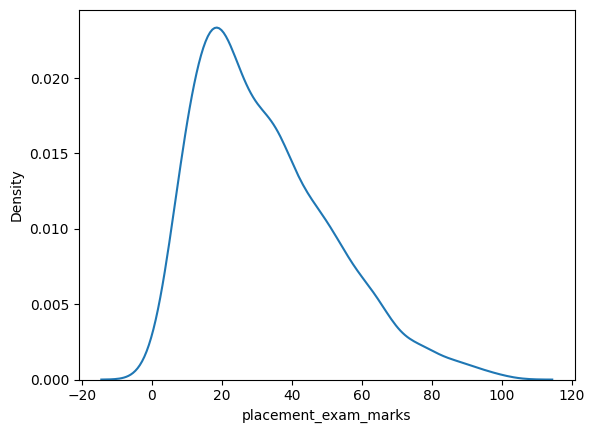

In [5]:
sns.kdeplot(x ='placement_exam_marks', data = df)

In [6]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

<Axes: ylabel='placement_exam_marks'>

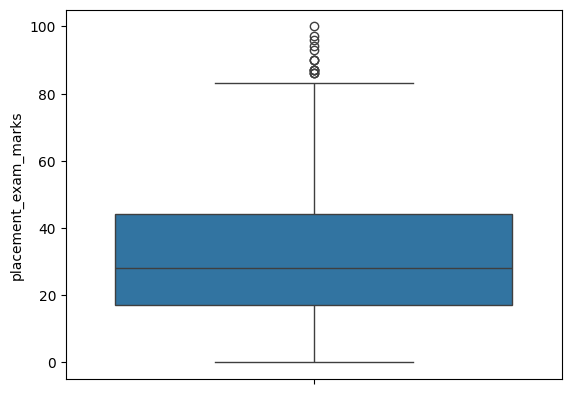

In [9]:
sns.boxplot(df['placement_exam_marks'])

In [12]:
### finding iqr
q1 = df['placement_exam_marks'].quantile(0.25)
q3= df['placement_exam_marks'].quantile(0.75)

In [13]:
iqr = q3 -q1

In [14]:
min_val = q1- 1.5*iqr
max_val = q3 + 1.5*iqr

### FINDING OUTLIERS

In [17]:
df[df['placement_exam_marks'] < min_val]

,cgpa,placement_exam_marks,placed


In [18]:
df[df['placement_exam_marks'] > max_val]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


### TRIMMING

In [19]:
new_df = df[(df['placement_exam_marks']>min_val) & (df['placement_exam_marks']<max_val)]

### Capping

In [20]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > max_val,
    min_val,
    np.where(
        new_df_cap['placement_exam_marks'] < max_val,
        min_val,
        new_df_cap['placement_exam_marks']
    )
)

C:\Users\NIKHI\AppData\Local\Temp\ipykernel_19044\415595997.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['placement_exam_marks'])
c:\MACHINE LEARNING ADVANCE\mlenv\Lib\site-packages\seaborn\distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


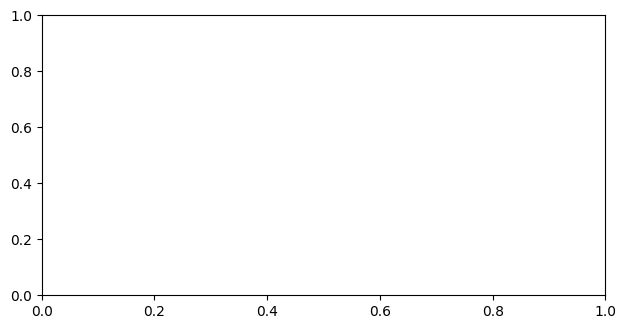

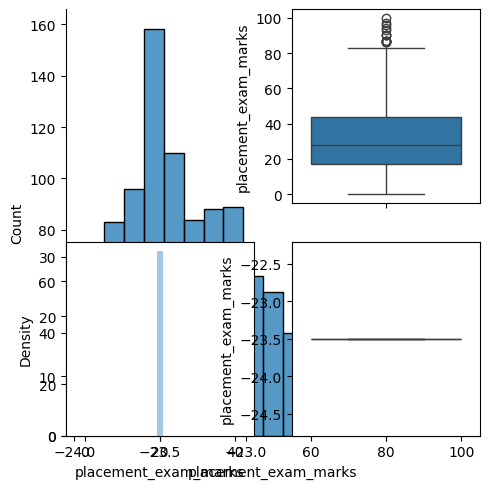

In [23]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.displot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()